Train shape: (7613, 5)
Test shape: (3263, 4)
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


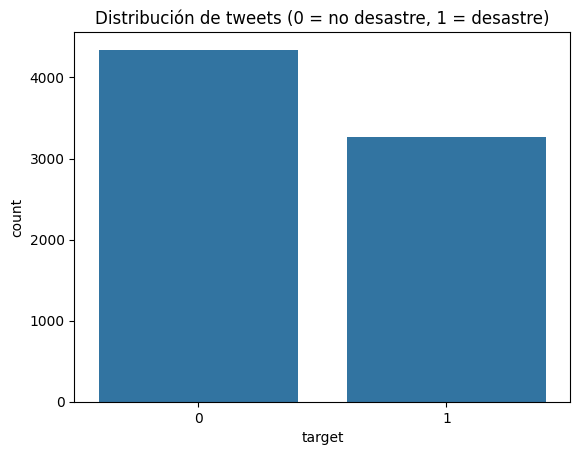

In [ ]:
import pandas as pd
import numpy as np
import math
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from collections import Counter
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from scipy.sparse import hstack, csr_matrix
from sklearn.base import clone

nltk.download('stopwords')
nltk.download('vader_lexicon')

stop_words = set(stopwords.words('english'))
sia = SentimentIntensityAnalyzer()
vader_lexicon = sia.lexicon

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print(train.isnull().sum())

sns.countplot(x="target", data=train)
plt.title("Distribución de tweets (0 = no desastre, 1 = desastre)")
plt.show()

**Distribucion de Tweets:**

El gráfico de barras muestra la distribución de tweets clasificados en:

0 = No desastre → ~4,300 tweets

1 = Desastre real → ~3,200 tweets

Aunque la diferencia no es extrema, sí existe un ligero desbalance de clases, hay más tweets que no son desastres que los que sí lo son.


**Tamaño del dataset**

Train shape: (7613, 5)

* 7,613 registros y 5 columnas

Test shape: (3263, 4)

* 3,263 registros y 4 columnas



## Procesamiento de datos

---
Para limpiar los tweets se transformara el texto pasandolo todo a minúsculas, eliminando URLs, menciones a @usuarios o #hashtags y algunos caracteres especiales

In [ ]:
def limpiar_texto_basico(text):
    if pd.isna(text): return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)

EMOTICON_RE = r"[:;=X][-oO\-]?[pPD\)\]\(\]/\\S]+"
EMOJI_RE = r'[\U0001F600-\U0001F64F]'

# como arriba pero revisando si hay emoticonos y despues miraremos si vale la pena o no usar los
# emoticonos debido a que es mas complejo evaluar si se usa el mismo para noticias tanto buenas
# como de desastre
def limpiar_texto_preservando_emoticons(text):
    if pd.isna(text): return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    tokens = text.split()
    clean_tokens = []
    for t in tokens:
        if re.search(EMOTICON_RE, t):
            clean_tokens.append(t)
            continue
        if re.search(r'[\U00010000-\U0010ffff]', t):
            clean_tokens.append(t)
            continue
        t2 = re.sub(r"[^a-zA-Z]", "", t)
        if t2 and t2 not in stop_words:
            clean_tokens.append(t2)
    return " ".join(clean_tokens)

train["clean_text"] = train["text"].apply(limpiar_texto_basico)
train["clean_text_sent"] = train["text"].apply(limpiar_texto_preservando_emoticons)

# Print para ver si funciona
display(train[["text","clean_text","clean_text_sent"]].head(15))

,text,clean_text,clean_text_sent
0,Our Deeds are the Reason of this #earthquake M...,deeds reason earthquake may allah forgive us,deeds reason earthquake may allah forgive us
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,residents asked shelter place notified officer...,residents asked shelter place notified officer...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders cal...,people receive wildfires evacuation orders cal...
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfires pou...,got sent photo ruby alaska smoke wildfires pou...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed directi...,rockyfire update california hwy closed directi...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,top hill see fire woods,im top hill see fire woods
8,There's an emergency evacuation happening now ...,emergency evacuation happening building across...,theres emergency evacuation happening building...
9,I'm afraid that the tornado is coming to our a...,afraid tornado coming area,im afraid tornado coming area


## Frecuencia de palabras

Palabras más comunes en tweets de desastre:
[('fire', 182), ('news', 148), ('amp', 135), ('disaster', 121), ('via', 121), ('california', 115), ('suicide', 112), ('police', 109), ('people', 105), ('killed', 95)]

Palabras más comunes en tweets NO desastre:
[('like', 254), ('amp', 209), ('new', 171), ('get', 163), ('one', 133), ('body', 116), ('would', 101), ('via', 99), ('video', 96), ('people', 94)]


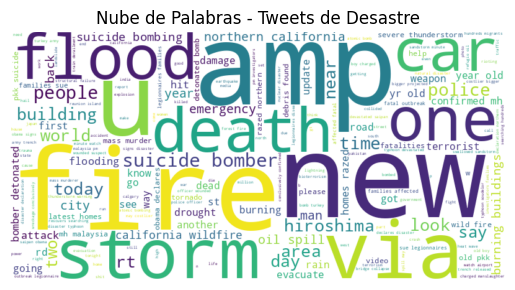

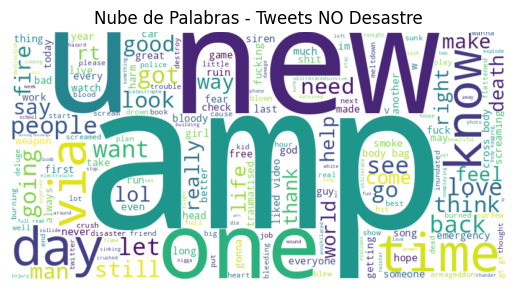

In [ ]:
def obtener_frecuencia(textos):
    all_words = " ".join(textos).split()
    return Counter(all_words)

freq_disaster = obtener_frecuencia(train[train["target"]==1]["clean_text"])
freq_nondisaster = obtener_frecuencia(train[train["target"]==0]["clean_text"])

print("Palabras más comunes en tweets de desastre:")
print(freq_disaster.most_common(10))

print("\nPalabras más comunes en tweets NO desastre:")
print(freq_nondisaster.most_common(10))

# Nube de palabras para desastres
wc_disaster = WordCloud(width=800, height=400, background_color="white").generate(" ".join(train[train["target"]==1]["clean_text"]))
plt.imshow(wc_disaster, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras - Tweets de Desastre")
plt.show()

# Nube de palabras para no desastres
wc_nondisaster = WordCloud(width=800, height=400, background_color="white").generate(" ".join(train[train["target"]==0]["clean_text"]))
plt.imshow(wc_nondisaster, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras - Tweets NO Desastre")
plt.show()


**Como se calcularon los n-gramas:**

Los n-gramas se generaron a partir del texto preprocesado de los tweets, donde primero se unieron todos los mensajes y luego se dividieron en palabras individuales. Despues, se utilizó la clase Counter de la librería collections en Python para contar la frecuencia de aparición de cada palabra, separando los tweets en dos grupos: aquellos relacionados con desastres (target=1) y los que no (target=0). Además, se calcularon las probabilidades de aparición de cada término sobre el total de palabras, lo que permite usar estas métricas y calcular la frecuencia y hacer el histograma.

## Histogramas

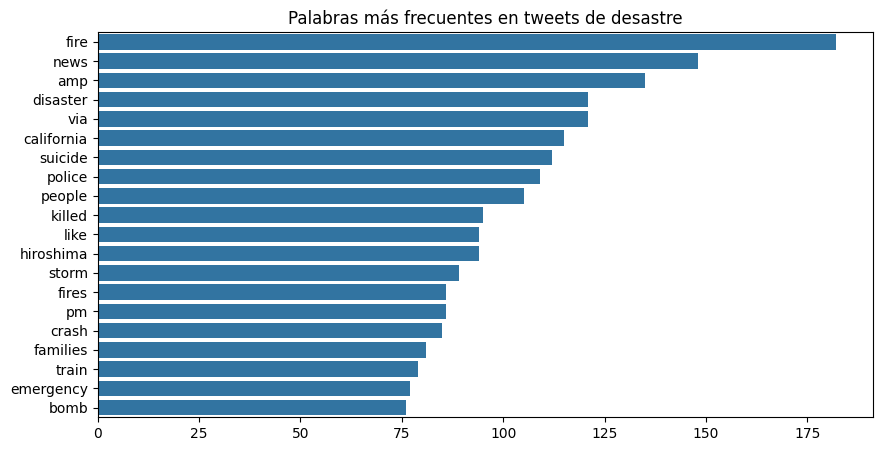

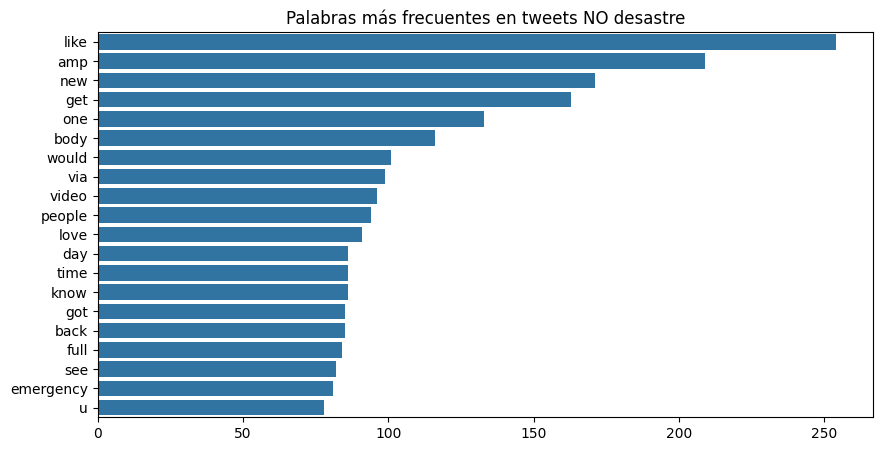

In [ ]:
def plot_top_words(freq, title):
    words, counts = zip(*freq.most_common(20))
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(title)
    plt.show()

plot_top_words(freq_disaster, "Palabras más frecuentes en tweets de desastre")
plot_top_words(freq_nondisaster, "Palabras más frecuentes en tweets NO desastre")


**Resultados de la frecuencia de las palabras y el histograma**

En los tweets de desastres, las palabras más frecuentes fueron fire, news, disaster, california, suicide, police y killed, términos directamente asociados a emergencias o catástrofes. En cambio, en los tweets que no corresponden a desastres predominaron palabras como like, new, get, one, body, would y video, que son de uso cotidiano y no hacen referencia a situaciones críticas.


## Paso 8 (funciones auxiliares, todavia no las usamos)

In [ ]:
# asigna una tag dependiendo el valor
def clasificar_palabra_lexicon(token):
    val = vader_lexicon.get(token, 0.0)
    if val > 0:
        return "pos"
    elif val < 0:
        return "neg"
    else:
        return "neu"

def contar_palabras_pos_neg_neu(text):
    toks = str(text).split()
    cpos = cneg = cneu = 0
    pos_list = []; neg_list = []; neu_list = []
    for t in toks:
        cls = clasificar_palabra_lexicon(t)
        if cls == "pos":
            cpos += 1; pos_list.append(t)
        elif cls == "neg":
            cneg += 1; neg_list.append(t)
        else:
            cneu += 1; neu_list.append(t)
    return {"pos": cpos, "neg": cneg, "neu": cneu, "pos_words": pos_list, "neg_words": neg_list}


## Preparar vectores para la clasificacion


--- Entrenando y evaluando: Naive Bayes ---
              precision    recall  f1-score   support

           0     0.7988    0.8907    0.8422       869
           1     0.8285    0.7018    0.7599       654

    accuracy                         0.8096      1523
   macro avg     0.8136    0.7963    0.8011      1523
weighted avg     0.8115    0.8096    0.8069      1523


--- Entrenando y evaluando: Logistic Regression ---
              precision    recall  f1-score   support

           0     0.8358    0.8377    0.8368       869
           1     0.7837    0.7813    0.7825       654

    accuracy                         0.8135      1523
   macro avg     0.8098    0.8095    0.8097      1523
weighted avg     0.8135    0.8135    0.8135      1523


--- Entrenando y evaluando: Random Forest ---
              precision    recall  f1-score   support

           0     0.7157    0.9298    0.8088       869
           1     0.8452    0.5092    0.6355       654

    accuracy                         

,accuracy,f1,precision,recall
LinearSVC,0.816809,0.785219,0.790698,0.779817
Logistic Regression,0.813526,0.782542,0.783742,0.781346
Naive Bayes,0.809586,0.759934,0.828520,0.701835
Random Forest,0.749179,0.635496,0.845178,0.509174


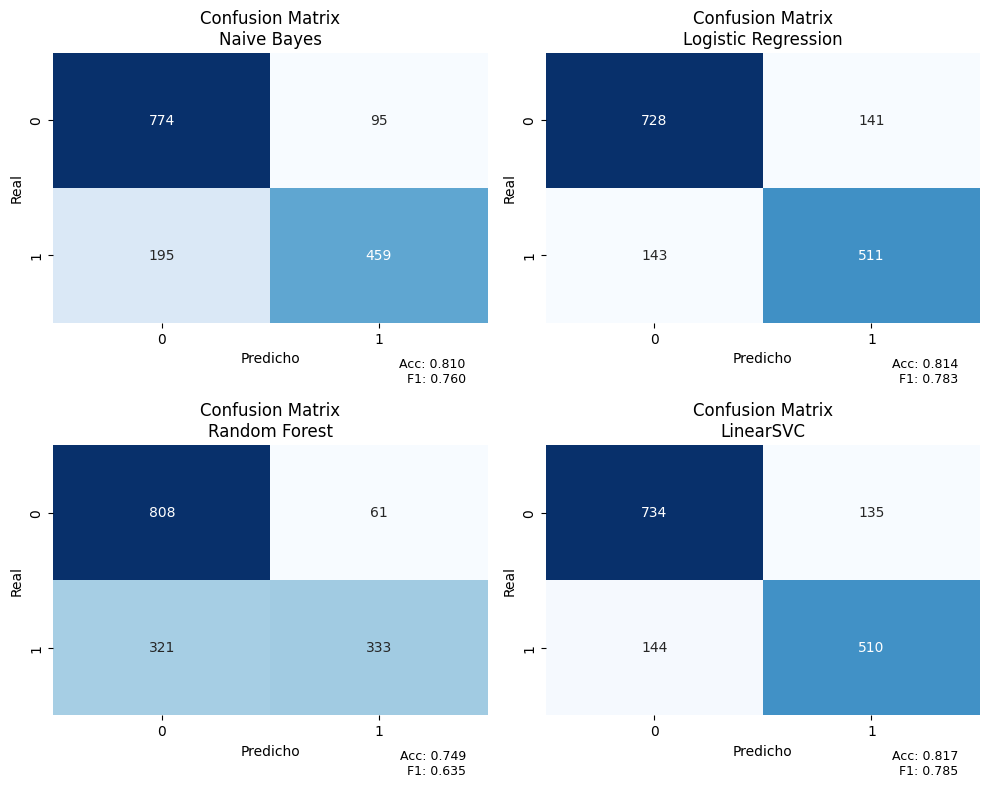

In [ ]:
X = train["clean_text"]
y = train["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(ngram_range=(1,2), stop_words="english", max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

modelos = {
    "Naive Bayes": MultinomialNB(
        alpha=0.1,
        fit_prior=True
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        C=1.0,
        penalty='l2',
        random_state=42,
        class_weight='balanced'
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=128,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42,
        class_weight='balanced',
        bootstrap=True,
        oob_score=True
    ),

    "LinearSVC": LinearSVC(
        max_iter=5000,
        C=0.1,
        penalty='l2',
        loss='squared_hinge',
        dual=False,
        random_state=42,
        class_weight='balanced'
    )
}

resultados = {}
metricas = {}

for name, model in modelos.items():
    print(f"\n--- Entrenando y evaluando: {name} ---")
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    y_score = None
    if hasattr(model, "predict_proba"):
        try:
            y_score = model.predict_proba(X_test_vec)[:, 1]
        except Exception:
            y_score = None
    elif hasattr(model, "decision_function"):
        try:
            y_score = model.decision_function(X_test_vec)
        except Exception:
            y_score = None

    resultados[name] = (model, y_pred, y_score)

    metricas[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred)
    }

    print(classification_report(y_test, y_pred, digits=4))

df_metricas = pd.DataFrame(metricas).T
display(df_metricas.sort_values("f1", ascending=False))

"""
Matrices de confusion para los modelos

"""

n_models = len(resultados)
cols = 2 if n_models <= 4 else 3
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for idx, (name, (model, y_pred, _)) in enumerate(resultados.items()):
    ax = axes[idx]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"Confusion Matrix\n{name}")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    acc = metricas[name]["accuracy"]
    f1 = metricas[name]["f1"]
    ax.text(0.95, -0.18, f"Acc: {acc:.3f}\nF1: {f1:.3f}", transform=ax.transAxes,
            ha="right", va="center", fontsize=9)

for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()

fig.savefig("confusion_matrices_all_models.png", dpi=150, bbox_inches="tight")

**¿Cómo planea abordar el contexto?**

Para abordar el contexto de los tweets se utilizó una representación basada en el contenido textual, principalmente con unigramas y n-gramas. Esto permite que el modelo no solo considere palabras individuales, sino también combinaciones frecuentes de palabras, que aportan más información sobre si un tweet describe un desastre real.

**Explicacion de los resultados:**

**Naive Bayes:** obtuvo una accuracy de 80.9%, destacando por su alta precisión de 82.8% en la clase de desastres, lo que significa que cuando predice que un tweet es de desastre, usualmente acierta. Sin embargo, su recall de 70.1% es más bajo, lo que indica que deja pasar varios tweets de desastre sin detectarlos.

**Logistic Regression:** mostró un rendimiento equilibrado con accuracy de 81.3% y métricas similares para ambas clases. Es más consistente que Naive Bayes, con un buen balance entre precision y recall.

**Random Forest:** tuvo el peor desempeño general accuracy de 74.9%. Aunque alcanzó una precisión alta en la clase de desastre 84.5%, su recall cayó hasta 50.9%, lo que significa que detecta muy pocos tweets de desastre correctamente y se inclina fuertemente hacia la clase "no desastre".

**LinearSVC:** resultó ser el mejor modelo, con la mayor accuracy de 81.7% y un f1-score de 0.785 en la clase de desastre. Se comporta de manera balanceada, logrando buena precisión 79.1% y buen recall 77.9%, lo cual lo hace más confiable para este problema.

**El mejor modelo:**

El modelo LinearSVC es el más adecuado para la tarea, seguido muy de cerca por Logistic Regression. Ambos superan a Naive Bayes y Random Forest en equilibrio entre precisión y recall.

**Analisis de la Matriz de confusion:**

**Naive Bayes:**

* Verdaderos negativos (VN): 774

* Falsos positivos (FP): 95

* Falsos negativos (FN): 195

* Verdaderos positivos (VP): 459

Interpretación:

* Clasifica bien la mayoría de los casos negativos de un desastre real.

* Se equivoca más cuando intenta identificar los desastres reales (195 falsos negativos).

**Logistic Regression:**

* VN: 728

* FP: 141

* FN: 143

* VP: 511

Interpretación:

* Tiene un balance más parejo que Naive Bayes: menos falsos negativos y bastantes verdaderos positivos.

* Mejora en la detección de la clase de desastres reales.

**Random Forest**

* VN: 808

* FP: 61

* FN: 321

* VP: 333

Interpretación:

* Excelente para detectar la clase de desastres falsos.

* Pero muy malo para la clase de desastres verdaderos, ya que deja escapar muchos positivos reales (321 falsos negativos).

**Linear SVC**


* VN: 734

* FP: 135

* FN: 144

* VP: 510

Interpretación:

* Muy similar a la regresión logística.

* Reconoce bien la clase de desastres reales (510 verdaderos positivos), con pocos errores.


## Funcion para clasificar

Nos sirve como prueba para ir depurando y viendo si los modelos funcionaron o necesitan mejorar para clasificar

In [ ]:
# Ahora agarramos el que nos tiro mejores resultados arriba y lo ponemos en "best_model" y este nos
# ayudara a clasificar el tweet [El que mejor sale es el Logistic o LinearSVC entre ellos tienen los mejores resultados y se alterna
# cual gana, asi que toca actualizar aqui abajo
best_model = resultados["LinearSVC"][0]
# La ultima vez que lo corri gano el LinearSVC con los hiperparametros que tiene

def clasificar_tweet(text, model=best_model, vectorizer=vectorizer, include_negativity=False):

    cleaned = limpiar_texto_basico(text)
    cleaned_sent = limpiar_texto_preservando_emoticons(text)
    # vectorizar
    x_vec = vectorizer.transform([cleaned])
    if include_negativity:
        neg_feat = calcular_negativity_numeric(cleaned_sent)
        x_vec = hstack([x_vec, csr_matrix(np.array([[neg_feat]]))])
    try:
        pred = model.predict(x_vec)[0]
    except Exception as e:
        pred = None
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(x_vec)[0].tolist()
    vader_scores = sia.polarity_scores(cleaned_sent)
    counts = contar_palabras_pos_neg_neu(cleaned_sent)
    return {
        "pred_label": int(pred),
        "pred_proba": proba,
        "cleaned": cleaned,
        "vader": vader_scores,
        "word_counts": counts
    }
# Aqui podemos agarrar un tweet del csv o del head de hace varios chunks y esto lo clasificara
print(clasificar_tweet("There is a fire in downtown!!! Many people injured :( #help"))


{'pred_label': 1, 'pred_proba': None, 'cleaned': 'fire downtown many people injured help', 'vader': {'neg': 0.584, 'neu': 0.219, 'pos': 0.197, 'compound': -0.6486}, 'word_counts': {'pos': 1, 'neg': 3, 'neu': 3, 'pos_words': ['help'], 'neg_words': ['fire', 'injured', ':(']}}


## Paso 8

Usamos las funciones que definimos antes, y ahora entrenamos para ver los resultados.

In [ ]:
# prueba en dataset para crear columnas con conteos y un score de 'negativity'
train_counts = train["clean_text_sent"].apply(contar_palabras_pos_neg_neu).apply(pd.Series)
# train = pd.concat([train, train_counts], axis=1) # train_counts contiene pos,neg,neu, pos_words, neg_words
train[['pos', 'neg', 'neu', 'pos_words', 'neg_words']] = train_counts

# variable numerica 'negativity'
train["negativity"] = train["neg"] - train["pos"]

# guardar VADER compound por observación
train["vader_compound"] = train["clean_text_sent"].apply(lambda t: sia.polarity_scores(t)["compound"])

"""
Paso 9 - usa las fucniones del paso 8
"""

# luego inspeccionamos 10 [tambien lo podemos cambiar para ver mejor el panorama]
# tweets más negativos y positivos
top10_mas_negativos = train.sort_values("negativity", ascending=False).head(10)
# para usar VADER compound en su lugar => sort_values("vader_compound")

top10_vader_neg = train.sort_values("vader_compound").head(10)
top10_vader_pos = train.sort_values("vader_compound", ascending=False).head(10)

print("Top 10 (VADER compound más negativo):")
display(top10_vader_neg[["text","clean_text_sent","vader_compound","target"]])

print("Top 10 (VADER compound más positivo):")
display(top10_vader_pos[["text","clean_text_sent","vader_compound","target"]])

# luego a comparar si los tweets de la categoría 'desastre' son más negativos que la otra categoría (punto 9.3)
agg = train.groupby("target")["vader_compound"].agg(["mean","median","count"])
print("Comparativa VADER compound por target (0 no desastre, 1 desastre):")
display(agg)

# Estadística simple: t-test para ver las diferencias en las medias
from scipy.stats import ttest_ind
a = train[train["target"]==1]["vader_compound"].dropna()
b = train[train["target"]==0]["vader_compound"].dropna()
tstat, pval = ttest_ind(a, b, equal_var=False)
print(f"T-test (compound): t={tstat:.4f}, p={pval:.4e} (H0: medias iguales)")

Top 10 (VADER compound más negativo):


,text,clean_text_sent,vader_compound,target
7472,wreck? wreck wreck wreck wreck wreck wreck wre...,wreck wreck wreck wreck wreck wreck wreck wrec...,-0.9879,0
6411,Suicide bomber kills 15 in Saudi security site...,suicide bomber kills saudi security site mosqu...,-0.9623,1
6393,? 19th Day Since 17-Jul-2015 -- Nigeria: Suici...,th day since jul nigeria suicide bomb attacks ...,-0.9595,1
6407,17 killed in SÛªArabia mosque suicide bombing...,killed sarabia mosque suicide bombing suicide ...,-0.9552,1
472,illegal alien released by Obama/DHS 4 times Ch...,illegal alien released obamadhs times charged ...,-0.9538,1
1540,Bomb Crash Loot Riot Emergency Pipe Bomb Nucle...,bomb crash loot riot emergency pipe bomb nucle...,-0.9524,1
6930,@cspan #Prez. Mr. President you are the bigges...,prez mr president biggest terrorist trouble ma...,-0.9493,1
2932,at the lake \n*sees a dead fish*\nme: poor lit...,lake sees dead fish poor little guy wonder hap...,-0.9477,0
4547,Udhampur terror attack: Militants attack polic...,udhampur terror attack militants attack police...,-0.9451,1
6818,Bomb head? Explosive decisions dat produced mo...,bomb head explosive decisions dat produced dea...,-0.9451,1


Top 10 (VADER compound más positivo):


,text,clean_text_sent,vader_compound,target
6992,Check out 'Want Twister Tickets AND A VIP EXPE...,check want twister tickets vip experience see ...,0.9682,0
3382,@batfanuk we enjoyed the show today. Great fun...,enjoyed show today great fun emergency non eva...,0.9423,0
3163,@batfanuk we enjoyed the show today. Great fun...,enjoyed show today great fun emergency non eva...,0.9423,0
6292,TodayÛªs storm will pass; let tomorrowÛªs li...,todays storm pass let tomorrows light greet ki...,0.9403,1
7182,@RogueWatson Nothing wrong with that. The Leth...,nothing wrong lethal weapon series great yes t...,0.9365,0
6140,Super sweet and beautiful :) https://t.co/TUi9...,super sweet beautiful :),0.9300,0
2238,#MeditationByMSG 45600 ppl got method of medit...,meditationbymsg ppl got method meditation ampg...,0.9287,0
7449,Having your wounds kissed by Someone who doesn...,wounds kissed someone doesnt see disasters sou...,0.9263,0
6295,Free Ebay Sniping RT? http://t.co/B231Ul1O1K L...,free ebay sniping rt lumbar extender back stre...,0.9260,0
6560,@duchovbutt @Starbuck_Scully @MadMakNY @davidd...,yeah survived seasons movies lets hope good th...,0.9217,0


Comparativa VADER compound por target (0 no desastre, 1 desastre):


,mean,median,count
target,,,
0,-0.052677,0.0000,4342
1,-0.264477,-0.3089,3271


T-test (compound): t=-21.0729, p=1.0606e-95 (H0: medias iguales)


**Algoritmo para clasificar en positivo, negativo o neutro:**

Para la clasificación del sentimiento de los tweets se utilizó un enfoque basado en lexicón y en el modelo VADER. En el primero, se contabilizó el número de palabras positivas, negativas y neutras de cada tweet, generando una variable llamada negativity definida como la diferencia entre palabras negativas y positivas. Con esta métrica, los tweets con valores positivos fueron clasificados como negativos, los que tuvieron valores negativos como positivos y los cercanos a cero como neutros. Paralelamente, se aplicó el modelo VADER, que calcula un puntaje compuesto entre -1 y 1, asignando etiquetas de positivo, negativo o neutral según umbrales predefinidos.

**¿valdrá la pena dejar los emoticones y analizarlos?**
En el preprocesamiento inicial se eliminaron los emoticones, sin embargo, vale la pena considerar su inclusión en futuros análisis porque aportan una fuerte carga emocional difícil de capturar solo con palabras. Los Emoticones transmiten de manera directa sentimientos positivos o negativos y, en el contexto de redes sociales, son elementos clave en la comunicación.


**Analisis de los resultados**

**9.1. ¿Cuáles son los 10 tweets más negativos? ¿En qué categoría están?**

Los 10 tweets más negativos según el puntaje VADER compound incluyen expresiones relacionadas con violencia, terrorismo, suicidios y bombas. Entre ellos destacan frases como “Suicide bomber kills 15 in Saudi security site mosque”, “17 killed in S’Arabia mosque suicide bombing”, “Udhampur terror attack” o “illegal alien released… charged”.

Distribución de categorías:

* 8 tweets pertenecen a la categoría de desastre real.

* 2 tweets pertenecen a la categoría no desastre



**9.2. ¿Cuáles son los 10 tweets más positivos? ¿En qué categoría están?**

Los 10 tweets más positivos incluyen mensajes con tono alegre, inspirador o promocional, como “Want Twister Tickets AND A VIP EXPERIENCE”, “we enjoyed the show today. Great fun”, “Today’s storm will pass; let tomorrow’s light greet”, “Super sweet and beautiful :)” o “Having your wounds kissed by Someone who doesn’t see disasters”.

Distribución de categorías:

* 8 tweets pertenecen a la categoría de no desastre.

* 2 tweets pertenecen a la categoría de desastre real.

**9.3. ¿Son los tweets de la categoría que indica que habla de un desastre real más negativos que los de la otra categoría?**

Sí. Según la tabla de promedios de VADER , los tweets de la categoría de desastre real tienen un puntaje medio de -0.264, mientras que los de la categoría de no desastre tienen un promedio mucho más cercano a la neutralidad -0.052. Además, la prueba estadística t-test (t = -21.07, p ≈ 1e-95) muestra que la diferencia entre ambas medias es altamente significativa.

In [ ]:
"""
PASO 10 : Ahora si vamos a incluir negativity como variable y vamos a reentrenar los modelos. Para replicabilidad vamos
a usar la misma limpieza de datos que en el paso 8 [clean_text] para TF-IDF y vamos a repetir el split pero ahora con la
nueva columna en cuenta (negativity)
"""
# copio el dataframe original que ya contiene 'negativity'
df = train.copy()
X_full = df["clean_text"]
neg_feat_all = df["negativity"].fillna(0).values.reshape(-1,1)
y_full = df["target"].astype(int)

# split (se conserva stratify y random_state para replicabilidad)
X_train2, X_test2, y_train2, y_test2, neg_train, neg_test = train_test_split(
    X_full, y_full, neg_feat_all, test_size=0.2, random_state=42, stratify=y_full
)

# vectorización con el TF-IDF ya entrenado anteriormente (vectorizer)
X_train_vec2 = vectorizer.transform(X_train2)
X_test_vec2  = vectorizer.transform(X_test2)

min_neg = neg_train.min()
if min_neg < 0:
    neg_train_shift = neg_train - min_neg
    neg_test_shift  = neg_test  - min_neg
else:
    neg_train_shift = neg_train.copy()
    neg_test_shift  = neg_test.copy()

# convertir a csr y concatenar
X_train_final = hstack([X_train_vec2, csr_matrix(neg_train_shift)])
X_test_final  = hstack([X_test_vec2, csr_matrix(neg_test_shift)])

# ----------------------------------------
# Reentrenar **todos** los modelos (con los mismos hiperparámetros que definiste)
# ----------------------------------------
# 'modelos' es el dict original que definiste arriba con los hyperparams.
results_with_neg = {}
metrics_with_neg = {}

for name, model in modelos.items():
    # clonar el estimador para iniciar desde cero con los mismos hiperparams
    m = clone(model)
    # entrenar sobre la matriz que incluye la feature 'negativity' (shifted)
    m.fit(X_train_final, y_train2)
    yp = m.predict(X_test_final)
    results_with_neg[name] = (m, yp)
    metrics_with_neg[name] = {
        "accuracy": accuracy_score(y_test2, yp),
        "f1": f1_score(y_test2, yp),
        "precision": precision_score(y_test2, yp),
        "recall": recall_score(y_test2, yp)
    }
    print(f"\n===== {name} (con neg) =====")
    print(classification_report(y_test2, yp, digits=4))

df_metrics_with_neg = pd.DataFrame(metrics_with_neg).T
display(df_metrics_with_neg.sort_values("f1", ascending=False))

# ----------------------------------------
# Comparar con las métricas previas (sin negativity) entrenadas sobre el mismo split
# para cada modelo original (mismas definiciones)
# ----------------------------------------
baseline_results = {}
baseline_metrics = {}

for name, model in modelos.items():
    m0 = clone(model)
    # entrenar solo con TF-IDF (sin la columna extra)
    m0.fit(vectorizer.transform(X_train2), y_train2)
    yp0 = m0.predict(vectorizer.transform(X_test2))
    baseline_results[name] = (m0, yp0)
    baseline_metrics[name] = {
        "accuracy": accuracy_score(y_test2, yp0),
        "f1": f1_score(y_test2, yp0),
        "precision": precision_score(y_test2, yp0),
        "recall": recall_score(y_test2, yp0)
    }
    print(f"\n===== {name} (baseline sin neg) =====")
    print(classification_report(y_test2, yp0, digits=4))

df_baseline = pd.DataFrame(baseline_metrics).T
display(df_baseline.sort_values("f1", ascending=False))

# Mostrar la delta (mejora/peor) entre usar negativity y no usarla
df_delta = df_metrics_with_neg - df_baseline
df_delta.columns = ["accuracy_delta", "f1_delta", "precision_delta", "recall_delta"]
# Reordenar e mostrar lado a lado
df_compare = pd.concat([df_baseline.add_suffix("_baseline"), df_metrics_with_neg.add_suffix("_with_neg"), df_delta], axis=1)
display(df_compare.sort_values("f1_with_neg", ascending=False))

# Imprimir resumen rápido de las mejoras
print("\nResumen (delta) — valores positivos indican mejora al incluir 'negativity':")
print(df_delta[["f1_delta","accuracy_delta"]].sort_values("f1_delta", ascending=False).round(4))



===== Naive Bayes (con neg) =====
              precision    recall  f1-score   support

           0     0.7998    0.8964    0.8454       869
           1     0.8361    0.7018    0.7631       654

    accuracy                         0.8129      1523
   macro avg     0.8179    0.7991    0.8042      1523
weighted avg     0.8154    0.8129    0.8100      1523


===== Logistic Regression (con neg) =====
              precision    recall  f1-score   support

           0     0.8312    0.8389    0.8351       869
           1     0.7833    0.7737    0.7785       654

    accuracy                         0.8109      1523
   macro avg     0.8073    0.8063    0.8068      1523
weighted avg     0.8106    0.8109    0.8108      1523


===== Random Forest (con neg) =====
              precision    recall  f1-score   support

           0     0.7328    0.9310    0.8201       869
           1     0.8568    0.5489    0.6692       654

    accuracy                         0.7669      1523
   macro avg 

,accuracy,f1,precision,recall
Logistic Regression,0.810900,0.778462,0.783282,0.773700
LinearSVC,0.810900,0.777090,0.786834,0.767584
Naive Bayes,0.812869,0.763092,0.836066,0.701835
Random Forest,0.766907,0.669152,0.856802,0.548930



===== Naive Bayes (baseline sin neg) =====
              precision    recall  f1-score   support

           0     0.7988    0.8907    0.8422       869
           1     0.8285    0.7018    0.7599       654

    accuracy                         0.8096      1523
   macro avg     0.8136    0.7963    0.8011      1523
weighted avg     0.8115    0.8096    0.8069      1523


===== Logistic Regression (baseline sin neg) =====
              precision    recall  f1-score   support

           0     0.8358    0.8377    0.8368       869
           1     0.7837    0.7813    0.7825       654

    accuracy                         0.8135      1523
   macro avg     0.8098    0.8095    0.8097      1523
weighted avg     0.8135    0.8135    0.8135      1523


===== Random Forest (baseline sin neg) =====
              precision    recall  f1-score   support

           0     0.7157    0.9298    0.8088       869
           1     0.8452    0.5092    0.6355       654

    accuracy                         0.7

,accuracy,f1,precision,recall
LinearSVC,0.816809,0.785219,0.790698,0.779817
Logistic Regression,0.813526,0.782542,0.783742,0.781346
Naive Bayes,0.809586,0.759934,0.828520,0.701835
Random Forest,0.749179,0.635496,0.845178,0.509174


,accuracy_baseline,f1_baseline,precision_baseline,recall_baseline,accuracy_with_neg,f1_with_neg,precision_with_neg,recall_with_neg,accuracy_delta,f1_delta,precision_delta,recall_delta
Logistic Regression,0.813526,0.782542,0.783742,0.781346,0.810900,0.778462,0.783282,0.773700,-0.002626,-0.004081,-0.000461,-0.007645
LinearSVC,0.816809,0.785219,0.790698,0.779817,0.810900,0.777090,0.786834,0.767584,-0.005909,-0.008130,-0.003864,-0.012232
Naive Bayes,0.809586,0.759934,0.828520,0.701835,0.812869,0.763092,0.836066,0.701835,0.003283,0.003158,0.007546,0.000000
Random Forest,0.749179,0.635496,0.845178,0.509174,0.766907,0.669152,0.856802,0.548930,0.017728,0.033656,0.011624,0.039755



Resumen (delta) — valores positivos indican mejora al incluir 'negativity':
                     f1_delta  accuracy_delta
Random Forest          0.0337          0.0177
Naive Bayes            0.0032          0.0033
Logistic Regression   -0.0041         -0.0026
LinearSVC             -0.0081         -0.0059


**Analisis de los resultados: **

aive Bayes (con neg): Accuracy 0.8129, F1 = 0.7631 → mejora leve respecto al modelo base (0.8096, 0.7599).

Logistic Regression (con neg): Accuracy 0.8109, F1 = 0.7785 → ligera disminución respecto al modelo base (0.8135, 0.7825).

Random Forest (con neg): Accuracy 0.7669, F1 = 0.6692 → mejora clara respecto al modelo base (0.7492, 0.6355).

Linear SVC (con neg): Accuracy 0.8109, F1 = 0.7771 → pequeña caída respecto al modelo base (0.8168, 0.7852).

**¿La inclusión de esta variable mejoró los resultados del modelo de clasificación?**

La inclusión de la variable de negativity no tuvo un impacto uniforme en todos los modelos: en algunos casos fue beneficiosa, mientras que en otros generó una ligera pérdida de rendimiento. Específicamente, ayudó a Naive Bayes y especialmente a Random Forest, que lograron mejoras en precisión general y en el equilibrio entre clases. Sin embargo, en Logistic Regression y Linear SVC, que ya mostraban un buen desempeño, la nueva variable no aportó información adicional y en cambio redujo su desempeño.

**¿En qué medida?**

La mejora más significativa se observó en Random Forest, que aumentó su accuracy en 1.8% y su F1 en 3.3 puntos, reduciendo el sesgo que tenía hacia la clase negativa. En Naive Bayes la mejora fue más modesta, de apenas 0.3% en accuracy y 0.3 puntos en F1, mostrando que la variable sí aporta información pero de manera limitada. En cambio, Logistic Regression perdió alrededor de 0.2% en accuracy y 0.4 puntos en F1, mientras que Linear SVC cayó cerca de 0.6% en accuracy y 0.8 puntos en F1. En conjunto, la variable negativity resultó más útil para modelos menos robustos (Naive Bayes y Random Forest), pero no mejoró e incluso afectó ligeramente a los modelos lineales más consistentes.